{'2022-23': 2460, '2020-21': 2160, '2013-14': 2460, '2018-19': 2460, '2012-13': 2458, '2017-18': 2460, '2019-20': 2118, '2014-15': 2460, '2023-24': 2460, '2015-16': 2460, '2021-22': 2460, '2010-11': 2460, '2016-17': 2460, '2011-12': 1980}
SEASON_YEAR             0
TEAM_ID                 0
TEAM_ABBREVIATION       0
TEAM_NAME               0
GAME_ID                 0
GAME_DATE               0
MATCHUP                 0
WL                      0
MIN                     0
FGM                     0
FGA                     0
FG_PCT                  0
FG3M                    0
FG3A                    0
FG3_PCT                 0
FTM                     0
FTA                     0
FT_PCT                  0
OREB                    0
DREB                    0
REB                     0
AST                     0
TOV                     0
STL                     0
BLK                     0
BLKA                    0
PF                      0
PFD                     0
PTS                     0
PLUS_MI

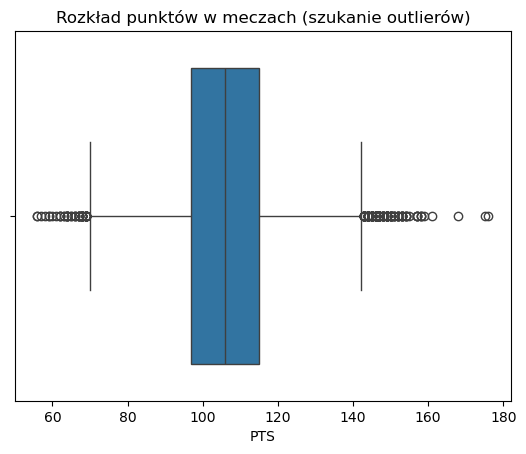

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_regular = pd.read_csv('../nba_playoff_predictor/regular_season_totals_2010_2024.csv')

df_regular.head()

all_matches_2014_15_regular = df_regular[df_regular['SEASON_YEAR'] == '2014-15']

seasons = df_regular['SEASON_YEAR'].unique()

seasons_matches_count = {}

for season in seasons:
    count = len(df_regular[df_regular['SEASON_YEAR'] == season])
    seasons_matches_count[season] = count



#eksploracja
print(seasons_matches_count)
print(df_regular.isnull().sum())
df_regular.drop('AVAILABLE_FLAG', axis=1, inplace=True)

print(df_regular[['PTS', 'PLUS_MINUS']].describe())

sns.boxplot(x=df_regular['PTS'])
plt.title('Rozkład punktów w meczach (szukanie outlierów)')
plt.show()

#all_matches_2014_15_regular[all_matches_2014_15_regular['GAME_ID'] == 21400939]


# Feature engineering

In [ ]:
# # 1. Tworzymy kolumnę pomocniczą (1 jeśli wygrana, 0 jeśli przegrana)
# # Pomoże nam to łatwo wyliczyć procent wygranych meczów (Win Percentage)
# df_regular['WIN_FLAG'] = df_regular['WL'].apply(lambda x: 1 if x == 'W' else 0)

# # 2. Grupujemy dane i wyliczamy ŚREDNIE dla każdego sezonu
# team_season_stats = df_regular.groupby(['SEASON_YEAR', 'TEAM_ABBREVIATION']).agg(
#     AVG_PLUS_MINUS=('PLUS_MINUS', 'mean'),  # Średnia różnica punktów
#     WIN_PCT=('WIN_FLAG', 'mean')            # Procent zwycięstw
# ).reset_index()

# # Podglądamy wyniki dla pierwszych 5 drużyn
# print(team_season_stats.head())

  SEASON_YEAR TEAM_ABBREVIATION  AVG_PLUS_MINUS   WIN_PCT
0     2010-11               ATL       -0.817073  0.536585
1     2010-11               BOS        5.365854  0.682927
2     2010-11               CHA       -4.000000  0.414634
3     2010-11               CHI        7.317073  0.756098
4     2010-11               CLE       -9.012195  0.231707


In [6]:
# 1. Tworzymy flagę wygranej i flagę Gospodarza (Home)
df_regular['WIN_FLAG'] = df_regular['WL'].apply(lambda x: 1 if x == 'W' else 0)

# Jeśli w MATCHUP jest 'vs.', to drużyna grała u siebie. Jeśli '@', to na wyjeździe.
df_regular['IS_HOME'] = df_regular['MATCHUP'].apply(lambda x: 1 if 'vs.' in x else 0)

# 2. Wyliczamy ogólne statystyki sezonowe
general_stats = df_regular.groupby(['SEASON_YEAR', 'TEAM_ABBREVIATION']).agg(
    AVG_PLUS_MINUS=('PLUS_MINUS', 'mean'),
    WIN_PCT=('WIN_FLAG', 'mean'),
    AVG_PTS=('PTS', 'mean')
).reset_index()

# 3. Wyliczamy procent wygranych TYLKO u siebie i TYLKO na wyjeździe
# Wybieramy tylko mecze u siebie (IS_HOME == 1) i liczymy dla nich średnią wygranych
home_stats = df_regular[df_regular['IS_HOME'] == 1].groupby(['SEASON_YEAR', 'TEAM_ABBREVIATION']).agg(
    HOME_WIN_PCT=('WIN_FLAG', 'mean')
).reset_index()

away_stats = df_regular[df_regular['IS_HOME'] == 0].groupby(['SEASON_YEAR', 'TEAM_ABBREVIATION']).agg(
    AWAY_WIN_PCT=('WIN_FLAG', 'mean')
).reset_index()

# 4. Łączymy wszystko w jeden potężny słownik za pomocą pd.merge()
team_season_stats = pd.merge(general_stats, home_stats, on=['SEASON_YEAR', 'TEAM_ABBREVIATION'])
team_season_stats = pd.merge(team_season_stats, away_stats, on=['SEASON_YEAR', 'TEAM_ABBREVIATION'])

print(team_season_stats.head())

  SEASON_YEAR TEAM_ABBREVIATION  AVG_PLUS_MINUS   WIN_PCT    AVG_PTS  \
0     2010-11               ATL       -0.817073  0.536585  95.000000   
1     2010-11               BOS        5.365854  0.682927  96.500000   
2     2010-11               CHA       -4.000000  0.414634  93.292683   
3     2010-11               CHI        7.317073  0.756098  98.621951   
4     2010-11               CLE       -9.012195  0.231707  95.451220   

   HOME_WIN_PCT  AWAY_WIN_PCT  
0      0.585366      0.487805  
1      0.804878      0.560976  
2      0.512195      0.317073  
3      0.878049      0.634146  
4      0.292683      0.170732  


In [9]:
def przygotuj_zbior_treningowy(sezon, df_mecze, df_slownik):
    # 1. Filtrujemy mecze tylko z wybranego sezonu
    df_sezon = df_mecze[df_mecze['SEASON_YEAR'] == sezon].copy()
    
    # 2. Wyciągamy nazwy drużyn grających w danym meczu
    # Gospodarze (IS_HOME == 1) - to nasza perspektywa
    gospodarze = df_sezon[df_sezon['IS_HOME'] == 1][['GAME_ID', 'TEAM_ABBREVIATION', 'WIN_FLAG']]
    gospodarze = gospodarze.rename(columns={'TEAM_ABBREVIATION': 'HOME_TEAM', 'WIN_FLAG': 'TARGET'})
    
    # Goście (IS_HOME == 0)
    goscie = df_sezon[df_sezon['IS_HOME'] == 0][['GAME_ID', 'TEAM_ABBREVIATION']]
    goscie = goscie.rename(columns={'TEAM_ABBREVIATION': 'AWAY_TEAM'})
    
    # Łączymy po GAME_ID, żeby mieć jeden wiersz na mecz: [GAME_ID, HOME_TEAM, AWAY_TEAM, TARGET]
    mecze_pary = pd.merge(gospodarze, goscie, on='GAME_ID')
    
    # 3. Pobieramy "słownik" tylko dla tego konkretnego sezonu
    slownik_sezon = df_slownik[df_slownik['SEASON_YEAR'] == sezon]
    
    # 4. Doklejamy statystyki Gospodarza
    dane_z_gospodarzem = pd.merge(mecze_pary, slownik_sezon, 
                                  left_on='HOME_TEAM', right_on='TEAM_ABBREVIATION')
    
    # 5. Doklejamy statystyki Gościa (pandas automatycznie doda przyrostki _x i _y jeśli kolumny mają te same nazwy, 
    # ale my użyjemy parametru suffixes, żeby mieć ładne nazwy _HOME i _AWAY)
    dane_kompletne = pd.merge(dane_z_gospodarzem, slownik_sezon, 
                              left_on='AWAY_TEAM', right_on='TEAM_ABBREVIATION', 
                              suffixes=('_HOME', '_AWAY'))
    
    # 6. MAGIA ML: LICZYMY RÓŻNICE (Deltę)
    # To jest to, co ostatecznie zobaczy model Regresji Logistycznej
    dane_kompletne['DELTA_PLUS_MINUS'] = dane_kompletne['AVG_PLUS_MINUS_HOME'] - dane_kompletne['AVG_PLUS_MINUS_AWAY']
    dane_kompletne['DELTA_WIN_PCT'] = dane_kompletne['WIN_PCT_HOME'] - dane_kompletne['WIN_PCT_AWAY']
    
    # Najważniejsza metryka inżynieryjna: porównujemy siłę domową gospodarza z siłą wyjazdową gościa!
    dane_kompletne['DELTA_HOME_AWAY_WIN_PCT'] = dane_kompletne['HOME_WIN_PCT_HOME'] - dane_kompletne['AWAY_WIN_PCT_AWAY']
    
    # 7. Zostawiamy tylko kolumny, których naprawdę potrzebujemy
    kolumny_do_modelu = [
        'GAME_ID', 'HOME_TEAM', 'AWAY_TEAM', 
        'DELTA_PLUS_MINUS', 'DELTA_WIN_PCT', 'DELTA_HOME_AWAY_WIN_PCT', 
        'TARGET'
    ]
    
    return dane_kompletne[kolumny_do_modelu]

# --- TESTUJEMY FUNKCJĘ ---
# Przekazujemy sezon 2014-15, surowe mecze i wyliczony wcześniej słownik
dane_treningowe_2014 = przygotuj_zbior_treningowy('2014-15', df_regular, team_season_stats)

print(f"Liczba meczów w zbiorze treningowym: {len(dane_treningowe_2014)}")
print("\nPróbka gotowych danych dla modelu:")
dane_treningowe_2014

Liczba meczów w zbiorze treningowym: 1230

Próbka gotowych danych dla modelu:


,GAME_ID,HOME_TEAM,AWAY_TEAM,DELTA_PLUS_MINUS,DELTA_WIN_PCT,DELTA_HOME_AWAY_WIN_PCT,TARGET
0,21400939,ATL,SAC,9.134146,0.378049,0.585366,1
1,21401117,HOU,SAC,7.146341,0.329268,0.463415,1
2,21400217,HOU,SAC,7.146341,0.329268,0.463415,1
3,21400700,CLE,SAC,8.182927,0.292683,0.487805,1
4,21400651,GSW,SAC,13.804878,0.463415,0.682927,1
...,...,...,...,...,...,...,...
1225,21400989,LAL,ATL,-12.268293,-0.475610,-0.317073,0
1226,21400779,MIN,ATL,-14.219512,-0.536585,-0.390244,0
1227,21400767,MEM,ATL,-2.182927,-0.060976,0.146341,1
1228,21400100,NYK,ATL,-14.743902,-0.524390,-0.365854,0


In [ ]:
test123 = dane_treningowe_2014.query('HOME_TEAM == "LAL"')

len(test123)

41

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# --- KROK 1: Przygotowanie X (Cechy) i y (Cel) ---
# X to nasze statystyki na podstawie których przewidujemy
X_train = dane_treningowe_2014[['DELTA_PLUS_MINUS', 'DELTA_WIN_PCT', 'DELTA_HOME_AWAY_WIN_PCT']]

# y to wynik meczu (1 = wygrana gospodarza, 0 = przegrana)
y_train = dane_treningowe_2014['TARGET']

# --- KROK 2: Normalizacja (Skalowanie) ---
scaler = StandardScaler()
# scaler "uczy się" jak duże są nasze liczby i od razu je spłaszcza do formatu zrozumiałego dla modelu
X_train_scaled = scaler.fit_transform(X_train) 

# --- KROK 3: Inicjalizacja i Trening Modelu ---
# Tworzymy naszego "Księgowego"
model = LogisticRegression()

# Uczymy model! To tutaj wykonywana jest cała zaawansowana matematyka i szukanie wag.
model.fit(X_train_scaled, y_train)

# --- SZYBKI TEST (SANITY CHECK) ---
# Każemy modelowi przewidzieć wyniki tych samych meczów, na których się właśnie uczył.
# W świecie ML nazywa się to "In-sample accuracy". 
# Nie jest to ostateczny test (bo model zna już te mecze), ale pozwala sprawdzić, czy model w ogóle "łapie" zasady koszykówki.
y_pred = model.predict(X_train_scaled)
skutecznosc = accuracy_score(y_train, y_pred)

print(f"Trening zakończony sukcesem!")
print(f"Skuteczność modelu na sezonie zasadniczym: {skutecznosc * 100:.2f}%")

# Zobaczmy, jakie wagi (mnożniki) model uznał za najważniejsze!
wagi = model.coef_[0]
print("\nUstalona Waga dla Różnicy Punktów:", round(wagi[0], 2))
print("Ustalona Waga dla Różnicy % Wygranych:", round(wagi[1], 2))
print("Ustalona Waga dla Przewagi Własnego Parkietu:", round(wagi[2], 2))

Trening zakończony sukcesem!
Skuteczność modelu na sezonie zasadniczym: 70.73%

Ustalona Waga dla Różnicy Punktów: 0.08
Ustalona Waga dla Różnicy % Wygranych: -0.03
Ustalona Waga dla Przewagi Własnego Parkietu: 1.14


In [14]:
# --- KROK 1: Wczytujemy plik z Playoffami ---
df_playoff = pd.read_csv('../nba_playoff_predictor/play_off_totals_2010_2024.csv') # Upewnij się, że ścieżka jest poprawna

# --- KROK 2: Przygotowujemy flagi (tak samo jak dla sezonu) ---
df_playoff['WIN_FLAG'] = df_playoff['WL'].apply(lambda x: 1 if x == 'W' else 0)
df_playoff['IS_HOME'] = df_playoff['MATCHUP'].apply(lambda x: 1 if 'vs.' in x else 0)
# (Usuwamy AVAILABLE_FLAG jeśli tam jest)
if 'AVAILABLE_FLAG' in df_playoff.columns:
    df_playoff.drop('AVAILABLE_FLAG', axis=1, inplace=True)

# --- KROK 3: Wywołujemy NASZĄ FUNKCJĘ ---
# Bierzemy kalendarz Playoffów 2014-15, ale jako "wiedzę" podajemy Słownik z Sezonu Zasadniczego!
dane_testowe_playoff = przygotuj_zbior_treningowy('2014-15', df_playoff, team_season_stats)

# --- KROK 4: Oddzielamy X (cechy) i y (cel) ---
X_test = dane_testowe_playoff[['DELTA_PLUS_MINUS', 'DELTA_WIN_PCT', 'DELTA_HOME_AWAY_WIN_PCT']]
y_test = dane_testowe_playoff['TARGET']

# --- KROK 5: Skalowanie (BARDZO WAŻNE: tylko transform!) ---
X_test_scaled = scaler.transform(X_test)

# --- KROK 6: Właściwa Predykcja ---
y_pred_playoff = model.predict(X_test_scaled)
skutecznosc_playoff = accuracy_score(y_test, y_pred_playoff)

print(f"Liczba rozegranych meczów w Playoffach 2014-15: {len(dane_testowe_playoff)}")
print(f"Skuteczność modelu na PLAYOFFACH: {skutecznosc_playoff * 100:.2f}%")

Liczba rozegranych meczów w Playoffach 2014-15: 81
Skuteczność modelu na PLAYOFFACH: 66.67%
